In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr

import xgboost as xgb
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful.")

All imports successful.


In [ ]:
wg  = pd.read_csv('LVI_WesternGhats1.csv')
bf  = pd.read_csv('LVI_BlackForest1.csv')
cer = pd.read_csv('LVI_Cerrado1.csv')

df = pd.concat([wg, bf, cer], ignore_index=True)

print(f"Total rows loaded: {len(df)}")
print(f"\nRows per region:")
print(df['region'].value_counts())
print(f"\nColumn names: {list(df.columns)}")
print(f"\nFirst 3 rows:")
print(df.head(3))
df = df.dropna()

df['rh98'] = df['rh98'].clip(0, 60)

for band in ['B2', 'B3', 'B4', 'B8']:
    df[band] = df[band].clip(0, 1)

print(f"Rows after cleaning: {len(df)}")
print(f"\nBasic statistics:")
print(df[['B2','B3','B4','B8','rh98']].describe().round(4))

Total rows loaded: 235906

Rows per region:
region
BlackForest     138650
Cerrado          71144
WesternGhats     26112
Name: count, dtype: int64

Column names: ['B2', 'B3', 'B4', 'B8', 'rh98', 'region']

First 3 rows:
       B2       B3      B4       B8       rh98        region
0  0.0311  0.05235  0.0363  0.28045  21.459999  WesternGhats
1  0.0280  0.04845  0.0284  0.29035   5.610000  WesternGhats
2  0.0269  0.04840  0.0257  0.32490  18.959999  WesternGhats
Rows after cleaning: 235906

Basic statistics:
                B2           B3           B4           B8         rh98
count  235906.0000  235906.0000  235906.0000  235906.0000  235906.0000
mean        0.0354       0.0572       0.0530       0.2587      14.0929
std         0.0163       0.0224       0.0320       0.0691      11.6463
min         0.0046       0.0076       0.0046       0.0022       1.1900
25%         0.0226       0.0399       0.0257       0.2142       4.2000
50%         0.0332       0.0548       0.0476       0.2504       

In [4]:
#Balance rows across regions
#Downsample larger regions to match the smallest one
#so the model doesn't overfit to Black Forest patterns

print("Before balancing:")
print(df['region'].value_counts())

min_rows = df.groupby('region').size().min()
print(f"\nSmallest region has {min_rows} rows — downsampling others to match")

balanced = []
for region, group in df.groupby('region'):
    balanced.append(group.sample(n=min_rows, random_state=42))

df = pd.concat(balanced).reset_index(drop=True)

print(f"\nAfter balancing:")
print(df['region'].value_counts())
print(f"Total rows: {len(df)}")


Before balancing:
region
BlackForest     138650
Cerrado          71144
WesternGhats     26112
Name: count, dtype: int64

Smallest region has 26112 rows — downsampling others to match

After balancing:
region
BlackForest     26112
Cerrado         26112
WesternGhats    26112
Name: count, dtype: int64
Total rows: 78336


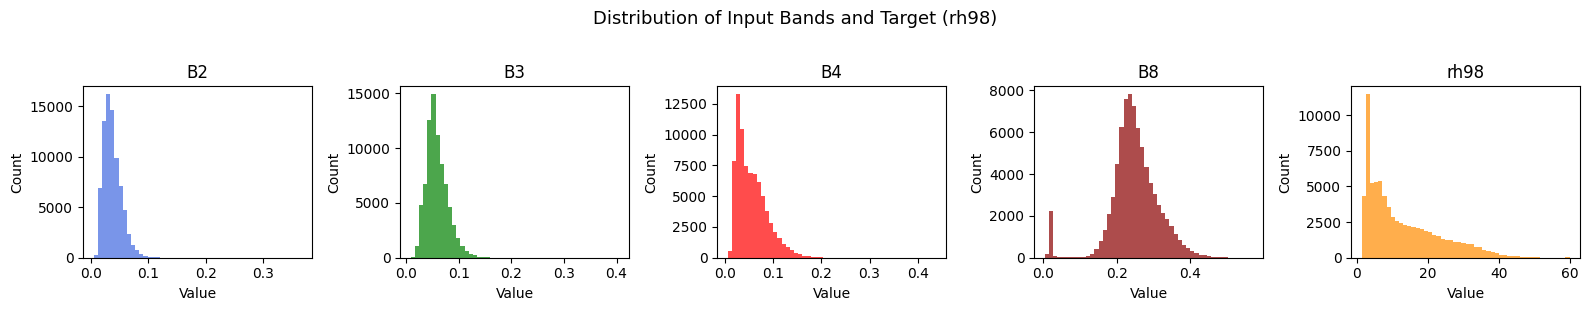

Saved: fig0_distributions_5.png


In [ ]:
#distribution check
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
cols   = ['B2', 'B3', 'B4', 'B8', 'rh98']
colors = ['royalblue', 'green', 'red', 'darkred', 'darkorange']

for ax, col, color in zip(axes, cols, colors):
    ax.hist(df[col], bins=50, color=color, alpha=0.7, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

plt.suptitle('Distribution of Input Bands and Target (rh98)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig0_distributions_5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig0_distributions_5.png")

In [ ]:
#Stratified 80/20 split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['region']
)

print(f"Training rows: {len(train_df)}")
print(f"Test rows:     {len(test_df)}")
print(f"\nRegion split in training set:")
print(train_df['region'].value_counts())
print(f"\nRegion split in test set:")
print(test_df['region'].value_counts())

#define features and target
FEATURES = ['B2', 'B3', 'B4', 'B8']
TARGET   = 'rh98'

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

#standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use same scaler, don't refit

print("Standardization done.")
print(f"Feature means (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Feature stds  (should be ~1): {X_train_scaled.std(axis=0).round(4)}")




Training rows: 62668
Test rows:     15668

Region split in training set:
region
BlackForest     20890
WesternGhats    20889
Cerrado         20889
Name: count, dtype: int64

Region split in test set:
region
Cerrado         5223
WesternGhats    5223
BlackForest     5222
Name: count, dtype: int64
Standardization done.
Feature means (should be ~0): [ 0. -0. -0.  0.]
Feature stds  (should be ~1): [1. 1. 1. 1.]


In [ ]:
#train XGBoost model
print("Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost training complete.")

Training XGBoost...
XGBoost training complete.


In [ ]:
#train MLP model
print("Training MLP (this may take a minute)...")

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=False
)

mlp_model.fit(X_train_scaled, y_train)
print("MLP training complete.")


Training MLP (this may take a minute)...
MLP training complete.


In [ ]:
#compute index baselines(NDVI, EVI, SAVI)
#X column order: [B2=0, B3=1, B4=2, B8=3]

def compute_ndvi(X):
    B4 = X[:, 2]   # Red
    B8 = X[:, 3]   # NIR
    return (B8 - B4) / (B8 + B4 + 1e-8)

def compute_evi(X):
    #enhanced Vegetation Index — reduces atmospheric + soil noise
    #EVI=2.5*(NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    B2 = X[:, 0]   #Blue
    B4 = X[:, 2]   #Red
    B8 = X[:, 3]   #NIR
    return 2.5 * (B8 - B4) / (B8 + 6*B4 - 7.5*B2 + 1 + 1e-8)

def compute_savi(X, L=0.5):
    #soil Adjusted Vegetation Index — corrects for soil background
    #SAVI = 1.5 * (NIR - Red) / (NIR + Red + L)
    B4 = X[:, 2]   # Red
    B8 = X[:, 3]   # NIR
    return 1.5 * (B8 - B4) / (B8 + B4 + L + 1e-8)

ndvi_test = compute_ndvi(X_test)
evi_test  = compute_evi(X_test)
savi_test = compute_savi(X_test)

print(f"NDVI range: {ndvi_test.min():.3f} to {ndvi_test.max():.3f}")
print(f"EVI  range: {evi_test.min():.3f} to {evi_test.max():.3f}")
print(f"SAVI range: {savi_test.min():.3f} to {savi_test.max():.3f}")


NDVI range: -0.675 to 0.900
EVI  range: -0.209 to 0.825
SAVI range: -0.150 to 0.701


In [10]:
#Linearly scale index baselines then evaluate all models

# NDVI, EVI, SAVI output values in [-1, 1] — not in metres.
# Directly computing RMSE against rh98 (metres) is not meaningful.
# Instead we fit a linear regression (index -> rh98) on the training
# set for each baseline, then use that scaled version on the test set.
# This finds the best possible linear mapping from each index to height,
# making the RMSE comparison fair against LVI.

from sklearn.linear_model import LinearRegression

def scale_index_to_height(index_train, index_test, y_train):
    """Fit a linear scaler from index values to rh98 on train set,
    apply to test set, return scaled test predictions."""
    lr = LinearRegression()
    lr.fit(index_train.reshape(-1, 1), y_train)
    return lr.predict(index_test.reshape(-1, 1))

# Compute index values on training set too (needed for fitting scaler)
ndvi_train = compute_ndvi(X_train)
evi_train  = compute_evi(X_train)
savi_train = compute_savi(X_train)

# Fit linear scalers and get scaled test predictions
ndvi_scaled = scale_index_to_height(ndvi_train, ndvi_test, y_train)
evi_scaled  = scale_index_to_height(evi_train,  evi_test,  y_train)
savi_scaled = scale_index_to_height(savi_train, savi_test, y_train)

print("Linear scaling fitted for NDVI, EVI, SAVI.")
print(f"  NDVI scaled range: {ndvi_scaled.min():.2f} to {ndvi_scaled.max():.2f} m")
print(f"  EVI  scaled range: {evi_scaled.min():.2f} to {evi_scaled.max():.2f} m")
print(f"  SAVI scaled range: {savi_scaled.min():.2f} to {savi_scaled.max():.2f} m")


def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    print(f"{name:20s} | RMSE: {rmse:.3f} m | Pearson r: {r:.3f} | R²: {r2:.3f}")
    return {'Model': name, 'RMSE': round(rmse, 3), 'Pearson_r': round(r, 3), 'R2': round(r2, 3)}

print("\n===== EVALUATION RESULTS (indices linearly scaled to metres) =====\n")
results = []
results.append(evaluate('NDVI (scaled)', y_test, ndvi_scaled))
results.append(evaluate('EVI  (scaled)', y_test, evi_scaled))
results.append(evaluate('SAVI (scaled)', y_test, savi_scaled))
results.append(evaluate('XGBoost (LVI)', y_test, xgb_model.predict(X_test_scaled)))
results.append(evaluate('MLP (LVI)',     y_test, mlp_model.predict(X_test_scaled)))

results_df = pd.DataFrame(results)
print("\nResults table:")
print(results_df.to_string(index=False))
results_df.to_csv('results_table_5.csv', index=False)
print("\nSaved: results_table_5.csv")




Linear scaling fitted for NDVI, EVI, SAVI.
  NDVI scaled range: -21.59 to 20.31 m
  EVI  scaled range: -3.91 to 26.38 m
  SAVI scaled range: -4.35 to 24.90 m

===== EVALUATION RESULTS (indices linearly scaled to metres) =====

NDVI (scaled)        | RMSE: 8.554 m | Pearson r: 0.565 | R²: 0.320
EVI  (scaled)        | RMSE: 9.588 m | Pearson r: 0.381 | R²: 0.145
SAVI (scaled)        | RMSE: 9.546 m | Pearson r: 0.391 | R²: 0.153
XGBoost (LVI)        | RMSE: 6.656 m | Pearson r: 0.767 | R²: 0.588
MLP (LVI)            | RMSE: 6.622 m | Pearson r: 0.770 | R²: 0.592

Results table:
        Model  RMSE  Pearson_r    R2
NDVI (scaled) 8.554      0.565 0.320
EVI  (scaled) 9.588      0.381 0.145
SAVI (scaled) 9.546      0.391 0.153
XGBoost (LVI) 6.656      0.767 0.588
    MLP (LVI) 6.622      0.770 0.592

Saved: results_table_5.csv


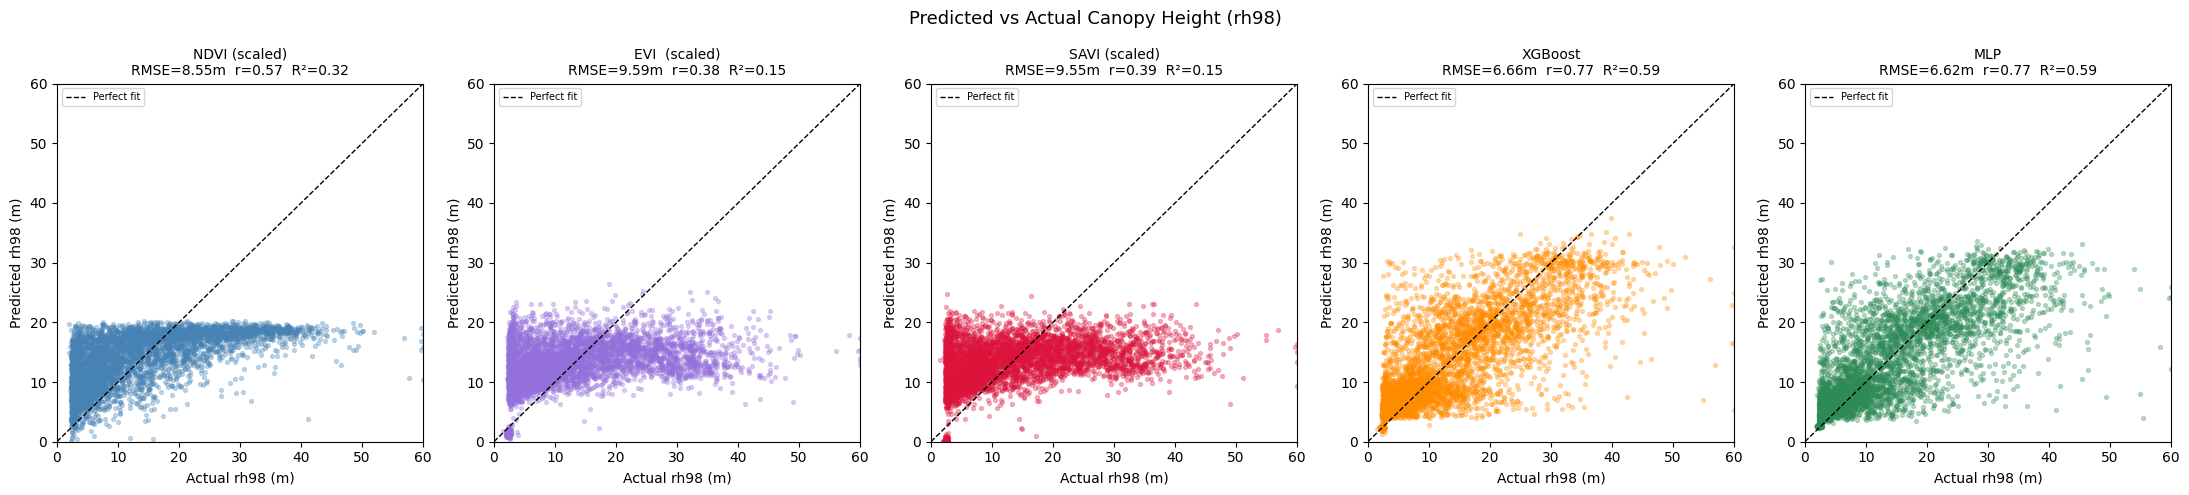

Saved: fig1_scatter_comparison_5.png


In [11]:
#Figure 1:Scatter plots (predicted vs actual)
xgb_preds = xgb_model.predict(X_test_scaled)
mlp_preds = mlp_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

# Use linearly scaled predictions for baselines so axes are in metres
models = [
    ('NDVI (scaled)', ndvi_scaled, 'steelblue'),
    ('EVI  (scaled)', evi_scaled,  'mediumpurple'),
    ('SAVI (scaled)', savi_scaled, 'crimson'),
    ('XGBoost', xgb_preds, 'darkorange'),
    ('MLP',     mlp_preds, 'seagreen'),
]

for ax, (name, preds, color) in zip(axes, models):
    idx = np.random.choice(len(y_test), size=min(5000, len(y_test)), replace=False)

    ax.scatter(y_test[idx], preds[idx], alpha=0.3, s=8, color=color)

    lims = [0, 60]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect fit')

    r, _ = pearsonr(y_test, preds)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)

    ax.set_title(f'{name}\nRMSE={rmse:.2f}m  r={r:.2f}  R²={r2:.2f}', fontsize=10)
    ax.set_xlabel('Actual rh98 (m)')
    ax.set_ylabel('Predicted rh98 (m)')
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 60)
    ax.legend(fontsize=7)

plt.suptitle('Predicted vs Actual Canopy Height (rh98)', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_scatter_comparison_5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_scatter_comparison_5.png")




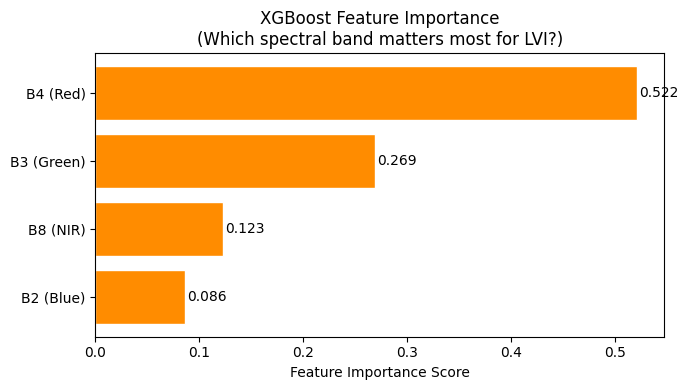

Saved: fig2_feature_importance_5.png


In [12]:
#Figure 2:Feature importance from XGBoost
importance = xgb_model.feature_importances_
feat_names = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B8 (NIR)']

sorted_idx   = np.argsort(importance)
sorted_imp   = importance[sorted_idx]
sorted_names = [feat_names[i] for i in sorted_idx]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(sorted_names, sorted_imp, color='darkorange', edgecolor='white')
ax.set_xlabel('Feature Importance Score')
ax.set_title('XGBoost Feature Importance\n(Which spectral band matters most for LVI?)')

for bar, val in zip(bars, sorted_imp):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig2_feature_importance_5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig2_feature_importance_5.png")




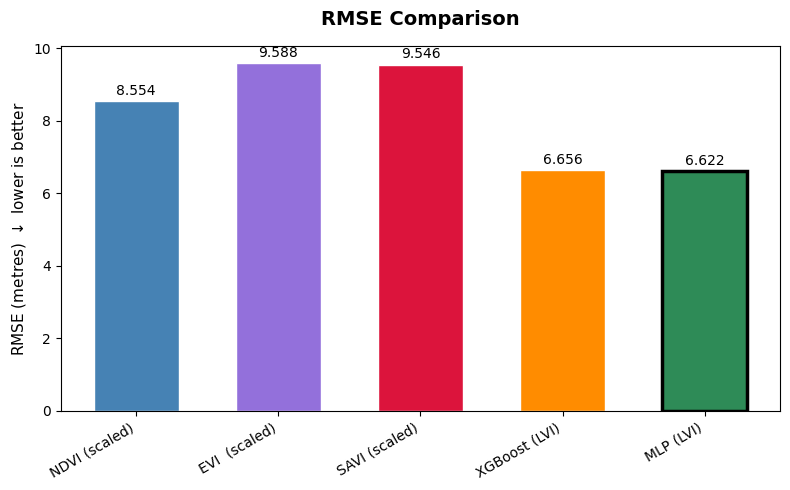

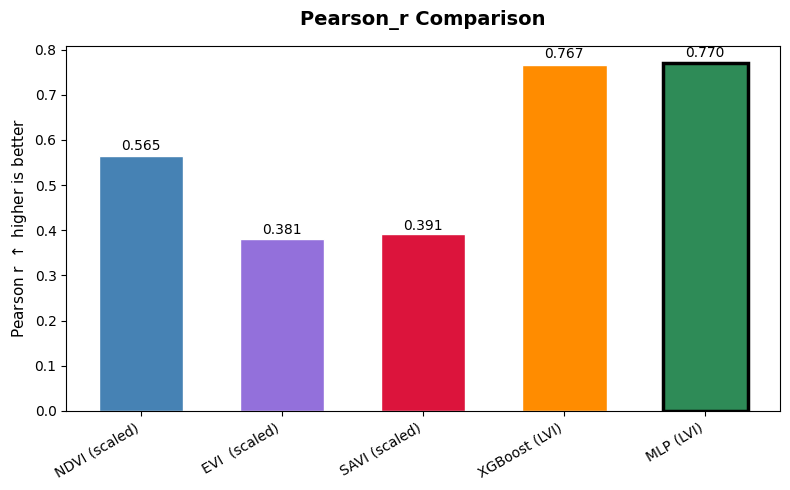

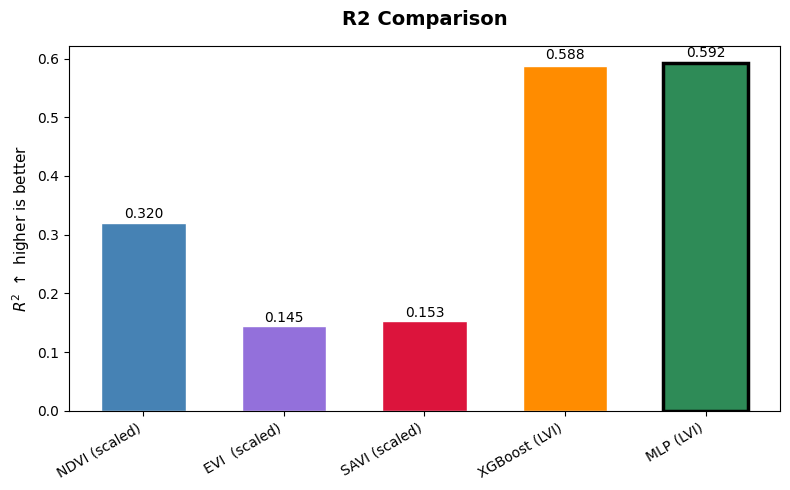

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Using your results_df
metrics  = ['RMSE', 'Pearson_r', 'R2']
ylabels  = [r'RMSE (metres) $\downarrow$ lower is better',
            r'Pearson r $\uparrow$ higher is better',
            r'$R^2$ $\uparrow$ higher is better']
colors   = ['steelblue', 'mediumpurple', 'crimson', 'darkorange', 'seagreen']

# Plotting each metric separately
for metric, ylabel in zip(metrics, ylabels):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    bars = ax.bar(
        results_df['Model'],
        results_df[metric],
        color=colors,
        edgecolor='white',
        width=0.6
    )
    
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=11)
    
    # Rotating x-labels and aligning them to prevent overlap
    ax.tick_params(axis='x', labelrotation=30)
    for label in ax.get_xticklabels():
        label.set_ha('right')

    # Adding value labels on top of bars
    for bar in bars:
        height = bar.get_height()
        offset = height * 0.01 if height > 0 else 0.01
        ax.text(bar.get_x() + bar.get_width()/2, height + offset,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

    # Highlight the best model (min for RMSE, max for others)
    if metric == 'RMSE':
        best_idx = results_df[metric].idxmin()
    else:
        best_idx = results_df[metric].idxmax()
        
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2.5)

    plt.tight_layout()
    plt.savefig(f'fig3_{metric.lower()}_comparison_5.png', dpi=150, bbox_inches='tight')


Running ablation study (removing one band at a time)...
  Without B2 (Blue): RMSE = 6.982 m
  Without B3 (Green): RMSE = 6.860 m
  Without B4 (Red): RMSE = 6.768 m
  Without B8 (NIR): RMSE = 6.812 m

Ablation results:
          Removed  RMSE
  None (baseline) 6.664
 Remove B2 (Blue) 6.982
Remove B3 (Green) 6.860
  Remove B4 (Red) 6.768
  Remove B8 (NIR) 6.812


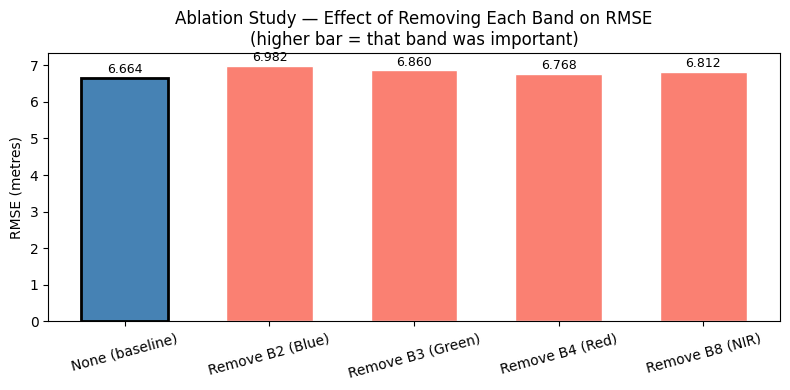

Saved: fig4_ablation_5.png


In [14]:
#Figure 4:Ablation study
print("\nRunning ablation study (removing one band at a time)...")

ablation_results = []

# Baseline: all 4 bands
xgb_base = xgb.XGBRegressor(n_estimators=300, max_depth=6,
                              learning_rate=0.05, random_state=42, verbosity=0)
xgb_base.fit(X_train_scaled, y_train)
base_rmse = np.sqrt(mean_squared_error(y_test, xgb_base.predict(X_test_scaled)))
ablation_results.append({'Removed': 'None (baseline)', 'RMSE': round(base_rmse, 3)})

band_names = ['B2 (Blue)', 'B3 (Green)', 'B4 (Red)', 'B8 (NIR)']
for i, bname in enumerate(band_names):
    keep_idx = [j for j in range(4) if j != i]
    X_tr_ab  = X_train_scaled[:, keep_idx]
    X_te_ab  = X_test_scaled[:, keep_idx]

    m = xgb.XGBRegressor(n_estimators=300, max_depth=6,
                          learning_rate=0.05, random_state=42, verbosity=0)
    m.fit(X_tr_ab, y_train)
    rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_te_ab)))
    ablation_results.append({'Removed': f'Remove {bname}', 'RMSE': round(rmse, 3)})
    print(f"  Without {bname}: RMSE = {rmse:.3f} m")

abl_df = pd.DataFrame(ablation_results)
print("\nAblation results:")
print(abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['steelblue'] + ['salmon'] * 4
bars = ax.bar(abl_df['Removed'], abl_df['RMSE'],
              color=bar_colors, edgecolor='white', width=0.6)

bars[0].set_edgecolor('black')
bars[0].set_linewidth(2)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.05,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('RMSE (metres)')
ax.set_title('Ablation Study — Effect of Removing Each Band on RMSE\n(higher bar = that band was important)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('fig4_ablation_5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig4_ablation_5.png")



In [15]:
#Save trained model
joblib.dump(xgb_model, 'lvi_xgboost_model_5.pkl')
joblib.dump(scaler,    'lvi_scaler_5.pkl')
print("Saved model: lvi_xgboost_model_5.pkl")
print("Saved scaler: lvi_scaler_5.pkl")


print("\n" + "="*50)
print("ALL DONE — files generated:")
print("="*50)
print("  fig0_distributions_5.png      — band & rh98 histograms")
print("  fig1_scatter_comparison_5.png — predicted vs actual")
print("  fig2_feature_importance_5.png — which band matters most")
print("  fig3_metrics_comparison_5.png — RMSE / r / R² bar chart")
print("  fig4_ablation_5.png           — ablation study")
print("  results_table_5.csv           — numbers for your paper table")
print("  lvi_xgboost_model_5.pkl       — saved model")
print("  lvi_scaler_5.pkl              — saved scaler")
print("="*50)

Saved model: lvi_xgboost_model_5.pkl
Saved scaler: lvi_scaler_5.pkl

ALL DONE — files generated:
  fig0_distributions_5.png      — band & rh98 histograms
  fig1_scatter_comparison_5.png — predicted vs actual
  fig2_feature_importance_5.png — which band matters most
  fig3_metrics_comparison_5.png — RMSE / r / R² bar chart
  fig4_ablation_5.png           — ablation study
  results_table_5.csv           — numbers for your paper table
  lvi_xgboost_model_5.pkl       — saved model
  lvi_scaler_5.pkl              — saved scaler
